In [1]:
#Importing the Essential libraries for my EDA and charts
import pandas as pd ## for data manipulation
import numpy as np # for numerical analysis
import plotly.express as px  # For interactive data visualization

##Turning off warnings
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [2]:
#importing the dataset
nova = pd.read_csv("nova_pay_transcations.csv")
nova.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [3]:
## Data preparation
## Handle missing values, fix data types, clean categorical fields, and extract useful time-based features
## from the timestamp. Address class imbalance if necessary.

### Data Inspection

In [4]:
#Top five rows
nova.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [5]:
## Last five rows 
nova.tail()


,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
10195,a5c6391d-4763-4ed6-a5ef-80b744cf71b2,af8ca4c4-8703-4c55-b66c-2b76cd70040d,2022-11-25 16:25:46.468549+00:00,US,USD,GBP,mobile,127.91,127.91,2.97,...,0.315,standard,1018,0.934,0,0.087,0,0,0.0,0
10196,35c133e7-7279-4d24-ac0e-967675f2c2a0,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2023-01-13 16:50:48.468549+00:00,US,USD,CNY,ATM,286.59,286.59,5.12,...,0.383,enhanced,257,0.894,0,0.257,0,0,0.0,0
10197,6263d697-0900-440c-99d7-b4be90e733b5,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2025-07-02 11:33:48.468549+00:00,US,USD,USD,mobile,230.09,230.09,4.01,...,0.244,enhanced,367,0.939,0,0.176,0,0,0.0,0
10198,883403f5-fd2f-4b39-824e-9710485a983e,7041b9c1-3719-4ca8-9a6b-811b47cea6c0,2023-01-01 02:40:14.468549+00:00,UK,GBP,PHP,mobile,-168.96,211.20,9999.99,...,1.200,standard,4,-0.100,0,0.407,-1,0,0.0,0
10199,f122f3ba-42fc-4018-85d1-57e71b525691,a07adabc-9a06-4e28-b1d6-83b128f4219a,2023-07-28 19:12:42.468549+00:00,US,USD,EUR,mobile,65.43,65.43,2.11,...,0.182,standard,859,0.810,0,0.363,0,0,0.0,0


In [6]:
# Checking te data types 
nova.dtypes

transaction_id                object
customer_id                   object
timestamp                     object
home_country                  object
source_currency               object
dest_currency                 object
channel                       object
amount_src                    object
amount_usd                   float64
fee                          float64
exchange_rate_src_to_dest    float64
device_id                     object
new_device                      bool
ip_address                    object
ip_country                    object
location_mismatch               bool
ip_risk_score                float64
kyc_tier                      object
account_age_days               int64
device_trust_score           float64
chargeback_history_count       int64
risk_score_internal          float64
txn_velocity_1h                int64
txn_velocity_24h               int64
corridor_risk                float64
is_fraud                       int64
dtype: object

In [7]:
nova.shape

(10200, 26)

In [8]:
nova.columns

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud'],
      dtype='object')

In [9]:
# Summary Statustics 
nova.describe()

,amount_usd,fee,exchange_rate_src_to_dest,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,9895.000000,9905.000000,10200.000000,10200.000000,10200.000000,9905.000000,10200.000000,10200.000000,10200.000000,10200.000000,10200.000000,10200.000000
mean,410.973958,110.915958,151.070118,0.355567,422.387353,0.684846,0.002549,0.241320,0.131471,0.232255,0.042412,0.019314
std,1428.534323,1013.983451,360.401932,0.230242,339.577111,0.254493,0.052334,0.103254,0.950315,0.981683,0.083074,0.137632
min,7.230000,-1.000000,0.592000,0.004000,4.000000,-0.100000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,88.260000,2.310000,1.000000,0.200000,257.000000,0.522000,0.000000,0.166000,0.000000,0.000000,0.000000,0.000000
50%,151.890000,3.330000,7.142857,0.308000,298.000000,0.779000,0.000000,0.223000,0.000000,0.000000,0.000000,0.000000
75%,267.935000,5.040000,61.666667,0.440000,718.000000,0.923000,0.000000,0.332000,0.000000,0.000000,0.000000,0.000000
max,12498.570000,9999.990000,1388.888889,1.200000,1092.000000,0.971000,2.000000,0.554000,8.000000,9.000000,0.250000,1.000000


In [10]:
# Display Index, Columns, and Data
nova.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             10200 non-null  object 
 1   customer_id                10200 non-null  object 
 2   timestamp                  10171 non-null  object 
 3   home_country               10200 non-null  object 
 4   source_currency            10200 non-null  object 
 5   dest_currency              10200 non-null  object 
 6   channel                    10200 non-null  object 
 7   amount_src                 10200 non-null  object 
 8   amount_usd                 9895 non-null   float64
 9   fee                        9905 non-null   float64
 10  exchange_rate_src_to_dest  10200 non-null  float64
 11  device_id                  10200 non-null  object 
 12  new_device                 10200 non-null  bool   
 13  ip_address                 9895 non-null   obj

In [11]:
#checking the shape of the data
nova.shape

(10200, 26)

In [12]:
## checking for missing values
nova.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   305
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

## Handling Missing Value

In [13]:
#making a copy of the original dataset
df = nova.copy()

In [14]:
df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [15]:
# Showing all rows that have at least one missing value
missing_rows = df[df.isnull().any(axis=1)]

missing_rows.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
13,1a34a095-3be4-4a69-a22e-803be566526c,7041b9c1-3719-4ca8-9a6b-811b47cea6c0,2022-10-05 07:04:39.468549+00:00,UK,GBP,EUR,mobile,322.24,NaN,NaN,...,0.245,NaN,4,NaN,0,0.407,0,0,0.05,0
49,b489474c-b729-4759-86e9-51778ddea385,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-08 20:45:48.468549+00:00,US,USD,INR,mobile,255.06,NaN,NaN,...,0.530,NaN,263,NaN,0,0.223,0,0,0.00,0
151,32cbd613-5c6c-4797-be15-165bc408c2ca,af8ca4c4-8703-4c55-b66c-2b76cd70040d,2022-10-20 22:08:59.468549+00:00,US,USD,MXN,mobile,502.97,NaN,NaN,...,0.310,NaN,1018,NaN,0,0.087,0,0,0.20,0
158,e6ef7b85-c19f-43fa-befa-743e37c62583,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,NaN,US,USD,PHP,mobile,248.92,248.92,5.56,...,0.197,enhanced,367,0.939,0,0.176,0,0,0.10,0
160,2b64ca36-f140-4de4-9cc8-c678255402a9,d71c91b4-fee8-4104-9856-a5c6109a62e3,NaN,US,USD,CNY,web,75.44,75.44,1.31,...,0.353,standard,298,0.336,0,0.166,0,0,0.00,0


In [16]:
##checking the shape of total missing values
missing_rows.shape

(334, 26)

In [17]:
# Total percentage of missing values in the DataFrame
total_missing_percent = (df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100

print(f"Total missing percentage: {total_missing_percent:.2f}%")

Total missing percentage: 0.69%


In [18]:
# Converting timestamp to proper datetime
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Extracting time-based features
df["hour"] = df["timestamp"].dt.hour                 # 0–23
df["day_of_week"] = df["timestamp"].dt.day_name()    # Monday, Tuesday, etc.
df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)

#Handling missing values created from invalid timestamps
# Filling numeric columns with unknown

df[["hour", "day_of_week", "is_weekend"]] = df[["hour", "day_of_week", "is_weekend"]].fillna(-1)
# Fill categorical column with a string marker
df["day_of_week"] = df["day_of_week"].fillna("Unknown")
df["timestamp"] = df["timestamp"].fillna("Unknown")



In [19]:
df.columns

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud', 'hour', 'day_of_week',
       'is_weekend'],
      dtype='object')

In [20]:
# Removing any whitespace(s)
df['amount_src'] = df['amount_src'].str.replace(' ', '')  # Remove any spaces

# Converting to numeric, setting errors='coerce' to handle non-convertible values
df['amount_src'] = pd.to_numeric(df['amount_src'], errors='coerce')

In [21]:
#Function to calculate the mean of some numeric columns
def calculate_mean(df, column_name):
    if column_name in df.columns:
        return df[column_name].mean()
    else:
        return "Column not found!"

# using the function
amount_usd = calculate_mean(df, 'amount_usd')
device_trust_score = calculate_mean(df, 'device_trust_score')
fee = calculate_mean(df, 'fee')

print("Mean of amount_usd:", amount_usd)
print("Mean of device_trust_score:", device_trust_score)
print("Mean of fee:", fee)


Mean of amount_usd: 410.97395755432035
Mean of device_trust_score: 0.684846340232206
Mean of fee: 110.91595759717313


In [22]:
# Numeric missing value handling using mean of each column to fill the missing values
num_fill_cols = [
    "amount_usd", "fee", "device_trust_score", "amount_src"
]

for col in num_fill_cols:
    if col in df.columns:
        mean_value = round(df[col].mean(), 2)  # Rounding the mean to two decimal places
        df[col] = df[col].fillna(mean_value)  

In [23]:
# Categorical missing value handling
cat_fill_cols = [
    "ip_address", "ip_country", "kyc_tier"
]

for col in cat_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna("unknown")  # Fill missing values with "unknown"

In [24]:
#Checking for missing values again
df.isnull().sum()

transaction_id               0
customer_id                  0
timestamp                    0
home_country                 0
source_currency              0
dest_currency                0
channel                      0
amount_src                   0
amount_usd                   0
fee                          0
exchange_rate_src_to_dest    0
device_id                    0
new_device                   0
ip_address                   0
ip_country                   0
location_mismatch            0
ip_risk_score                0
kyc_tier                     0
account_age_days             0
device_trust_score           0
chargeback_history_count     0
risk_score_internal          0
txn_velocity_1h              0
txn_velocity_24h             0
corridor_risk                0
is_fraud                     0
hour                         0
day_of_week                  0
is_weekend                   0
dtype: int64

In [25]:
# converting timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Extracting year, filling NaNs with 0
df['year'] = df['timestamp'].dt.year.fillna(0).astype(int)



## Insights and charts

In [26]:

# Creating a bar plot
fig_day = px.bar(
    df.groupby('day_of_week').size().reset_index(name='number_of_deposits'),
    x='day_of_week', 
    y='number_of_deposits',
    title='Number of Deposits by Day of the Week',
    labels={'number_of_deposits': 'Number of Deposits', 'day_of_week': 'Day of the Week'},
    text='number_of_deposits'
)

# Setting colors and hover template
fig_day.update_traces(marker_color='green', hovertemplate='Total Deposits: %{y}<extra></extra>')

# Displaying the figure
fig_day.show()

In [27]:

# Grouping by home_country and summing amounts
country_amount = df.groupby('home_country')['amount_src'].sum().reset_index(name='total_amount')

# Rounding total_amount to 2 decimal places
country_amount['total_amount'] = country_amount['total_amount'].round(2)

# Creating the bar plot for total amount by Home Country
fig_country = px.bar(
    country_amount,
    x='home_country', 
    y='total_amount',
    title='Total Amount by Home Country',
    labels={'total_amount': 'Total Amount', 'home_country': 'Home Country'},
    text='total_amount'  # Adding values on top of the bars
)

# Setting colors and hover template
fig_country.update_traces(marker_color='green', hovertemplate='Total Amount: %{y}<extra></extra>')

# Displaying the figure
fig_country.show()

In [28]:
##finding the total sum in USD
total_amount = df['amount_src'].sum()
print("Total sum of amount:", total_amount)

Total sum of amount: 4030938.05


In [29]:
##finding the total sum of feein USD
total_fee = df['fee'].sum()
print("Total sum of the fee:", fee)

Total sum of the fee: 110.91595759717313


In [30]:
##Finding the total fraud count
total_amount = df['is_fraud'].sum()
print("Total sum of the amount:", total_amount)

Total sum of the amount: 197


In [31]:

# Grouping by home_country and summing the number of frauds
country_fraud = df.groupby('home_country')['is_fraud'].sum().reset_index(name='total_fraud')

# Create the bar plot for total fraud transactions by home country
fig_country_fraud = px.bar(
    country_fraud,
    x='home_country', 
    y='total_fraud',
    title='Total Fraud Transactions by Home Country',
    labels={'total_fraud': 'Total Fraud Transactions', 'home_country': 'Home Country'},
    text='total_fraud'  # Adding values on top of the bars
)

# Setting colors and hover template
fig_country_fraud.update_traces(marker_color='green', hovertemplate='Total Fraud: %{y}<extra></extra>')

# Displaying the figure
fig_country_fraud.show()

In [32]:
df['chargeback_history_count'].value_counts()

chargeback_history_count
0    10175
1       24
2        1
Name: count, dtype: int64

In [33]:
df['kyc_tier'].value_counts()

kyc_tier
standard       7401
enhanced       1715
low             483
unknown         332
standrd          72
STANDARD         70
 standard        65
 enhanced        17
ENHANCED         17
enhancd          12
 low              8
LOW               5
 nan              2
NAN               1
Name: count, dtype: int64

In [34]:

# Standardizing kyc_tier values
df['kyc_tier'] = df['kyc_tier'].str.strip().str.lower().replace({
    'standrd': 'standard',
    'enhancd': 'enhanced',
    'nan': 'unknown'
}).fillna('unknown')

# Retain only necessary values
valid_kyc_tiers = ['standard', 'enhanced', 'low', 'unknown']
df = df[df['kyc_tier'].isin(valid_kyc_tiers)]


In [35]:
df['kyc_tier'].value_counts()

kyc_tier
standard    7608
enhanced    1761
low          496
unknown      335
Name: count, dtype: int64

In [36]:

# Grouping by home_country and suming the number of frauds
country_fraud = df.groupby('kyc_tier')['amount_src'].sum().reset_index(name='total_amount')

# Create the bar plot
fig_country_fraud = px.bar(
    country_fraud,
    x='kyc_tier', 
    y='total_amount',
    title='Total Fraud Transactions by KYC Tier',
    labels={'total_amount': 'Total Fraud Transactions', 'kyc_tier': 'KYC Tier'},
    color='total_amount',
    text='total_amount',  # Adding values on top of the bars
)
#fig_country_fraud.update_traces(marker_color='green')  # Set all bars to green
fig_country_fraud.update_traces(marker_color='green', hovertemplate='Total Fraud: %{y}<extra></extra>')



# Display the figure
fig_country_fraud.show()

In [37]:

# # Grouping by kyc_tier and summing the amounts
# country_fraud = df.groupby('kyc_tier')['amount_src'].sum().reset_index(name='total_amount')

# # Rounding total_amount to 2 decimal places
# country_fraud['total_amount'] = country_fraud['total_amount'].round(2)

# # Create the bar plot for total amounts by KYC tier
# fig_country_fraud = px.bar(
#     country_fraud,
#     x='kyc_tier', 
#     y='total_amount',
#     title='Total Amount by KYC Tier',
#     labels={'total_amount': 'Total Amount', 'kyc_tier': 'KYC Tier'},
#     text='total_amount'  # Adding values on top of the bars
# )

# # Setting all bars to green
# fig_country_fraud.update_traces(marker_color='green', hovertemplate='Total Amount: %{y}<extra></extra>')

# # Displaying the figure
# fig_country_fraud.show()

In [38]:

# Grouping by kyc_tier and summing the amounts
country_fraud = df.groupby('kyc_tier')['amount_src'].sum().reset_index(name='total_amount')

# Rounding total_amount to 2 decimal places
country_fraud['total_amount'] = country_fraud['total_amount'].round(2)

# Create the pie chart for total amounts by KYC tier
fig_country_fraud = px.pie(
    country_fraud,
    names='kyc_tier',
    values='total_amount',
    title='Total Amount by KYC Tier',
    labels={'total_amount': 'Total Amount', 'kyc_tier': 'KYC Tier'},
)

# Displaying the figure
fig_country_fraud.show()

In [39]:
## Dropping unwanted columns

df2 = df.drop(columns=['customer_id', 'transaction_id', 'timestamp', 'is_weekend',
                       'hour', 'device_id', 'ip_address', 'transaction_id', 'chargeback_history_count', 'txn_velocity_1h', 
                       'ip_risk_score', 'ip_country', 'new_device'
                       ])

In [40]:

df2.head()
df2.to_csv("nova_cleaned_data_for_web_app.csv", index=False)


In [41]:
df2['dest_currency'].value_counts()

dest_currency
USD    1253
CNY    1237
GBP    1208
CAD    1204
NGN    1190
INR    1164
PHP    1155
EUR    1113
MXN     676
Name: count, dtype: int64

In [42]:
# Drop rows where all values are NaN
df2 = df2.dropna(how='all')


In [43]:
# Define the replacement dictionary
channel_replacements = {
    'mobille': 'mobile',
    ' mobile': 'mobile',
    'MOBILE': 'mobile',
    'WEB': 'web',
    ' web': 'web',
    'weeb': 'web',
    'ATm': 'ATM',
    ' ATM': 'ATM',
    'unknown': 'unknown'
}

# Apply the replacements using the dictionary
df2['channel'] = df2['channel'].replace(channel_replacements)

# Optional: If you want to standardize casing and remove leading/trailing spaces
df2['channel'] = df2['channel'].str.strip().str.lower()

# Verify the result
channel_counts = df2['channel'].value_counts()
print(channel_counts)

channel
mobile     6063
web        3179
atm         921
unknown      37
Name: count, dtype: int64


In [44]:
# Grouping by channel and sum amount_src
kyc_amount = df2.groupby('channel')['amount_src'].sum().reset_index(name='total_amount')

# Create the pie chart
fig_kyc = px.pie(
    kyc_amount,
    names='channel', 
    values='total_amount',
    title='Total Amount by Channel'
)

# Display the figure
fig_kyc.show()

In [45]:
df2['home_country'].value_counts()


home_country
US         7287
UK         1797
CA          996
 US          68
unknown      32
 UK          13
 CA           7
Name: count, dtype: int64

In [46]:
# Define the replacement dictionary
home_country_replacements = {
    ' US': 'US',
    ' UK': 'UK',
    ' CA': 'CA',
    'unknown': 'unknown'
}

# Apply the replacements using the dictionary
df2['home_country'] = df2['home_country'].replace(home_country_replacements)

# Optional: If you want to standardize casing and remove leading/trailing spaces
df2['home_country'] = df2['home_country'].str.strip().str.lower()

# Verify the result
home_country_counts = df2['home_country'].value_counts()
print(home_country_counts)

home_country
us         7355
uk         1810
ca         1003
unknown      32
Name: count, dtype: int64


In [47]:
df2.columns

Index(['home_country', 'source_currency', 'dest_currency', 'channel',
       'amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest',
       'location_mismatch', 'kyc_tier', 'account_age_days',
       'device_trust_score', 'risk_score_internal', 'txn_velocity_24h',
       'corridor_risk', 'is_fraud', 'day_of_week', 'year'],
      dtype='object')

In [48]:
df2['source_currency'].value_counts()

source_currency
USD    7378
GBP    1817
CAD    1005
Name: count, dtype: int64

In [49]:
df2['dest_currency'].value_counts()

dest_currency
USD    1253
CNY    1237
GBP    1208
CAD    1204
NGN    1190
INR    1164
PHP    1155
EUR    1113
MXN     676
Name: count, dtype: int64

In [50]:
df2['location_mismatch'].value_counts()

location_mismatch
False    9009
True     1191
Name: count, dtype: int64

In [51]:
df2['day_of_week'].value_counts()

day_of_week
Monday       1500
Thursday     1488
Friday       1466
Tuesday      1428
Saturday     1428
Wednesday    1421
Sunday       1408
-1             61
Name: count, dtype: int64

In [52]:
# Replaceing -1 with unknown in the weekday column
df2['day_of_week'] = df2['day_of_week'].replace(-1, 'unknown')

# Verify the result
day_of_week_counts = df2['day_of_week'].value_counts()
print(day_of_week_counts)

day_of_week
Monday       1500
Thursday     1488
Friday       1466
Tuesday      1428
Saturday     1428
Wednesday    1421
Sunday       1408
unknown        61
Name: count, dtype: int64


In [53]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
import pickle

In [54]:
print(df2.columns)

Index(['home_country', 'source_currency', 'dest_currency', 'channel',
       'amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest',
       'location_mismatch', 'kyc_tier', 'account_age_days',
       'device_trust_score', 'risk_score_internal', 'txn_velocity_24h',
       'corridor_risk', 'is_fraud', 'day_of_week', 'year'],
      dtype='object')


In [55]:
from sklearn.preprocessing import LabelEncoder

# Define the categorical columns
categorical_cols = [
    "channel",
    "home_country",
    "kyc_tier",
    "source_currency",
    "dest_currency",
    "location_mismatch", 
    "day_of_week"
]

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Label encode each categorical column
for col in categorical_cols:
    df2[col] = label_encoder.fit_transform(df2[col].astype(str))

# Display the modified DataFrame (optional)
df2.head()

,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,location_mismatch,kyc_tier,account_age_days,device_trust_score,risk_score_internal,txn_velocity_24h,corridor_risk,is_fraud,day_of_week,year
0,3,2,0,0,278.19,278.19,4.25,1.351351,0,2,263,0.522,0.223,0,0.0,0,1,2022
1,0,0,5,3,208.51,154.29,4.24,12.758621,0,2,947,0.475,0.268,1,0.0,0,1,2022
2,3,2,1,1,160.33,160.33,2.70,7.142857,0,0,367,0.939,0.176,0,0.0,0,1,2022
3,3,2,2,1,59.41,59.41,2.22,0.925926,0,2,147,0.551,0.391,0,0.0,0,5,2022
4,3,2,4,1,200.96,200.96,3.61,83.333333,0,0,257,0.894,0.257,0,0.0,0,5,2022


In [56]:
df2['year'].value_counts()

year
2024    3395
2023    3373
2025    2578
2022     793
0         61
Name: count, dtype: int64

In [57]:
df2.to_csv("nova_pay_transactions_cleaned.csv", index=False)

In [58]:
df2.head()

,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,location_mismatch,kyc_tier,account_age_days,device_trust_score,risk_score_internal,txn_velocity_24h,corridor_risk,is_fraud,day_of_week,year
0,3,2,0,0,278.19,278.19,4.25,1.351351,0,2,263,0.522,0.223,0,0.0,0,1,2022
1,0,0,5,3,208.51,154.29,4.24,12.758621,0,2,947,0.475,0.268,1,0.0,0,1,2022
2,3,2,1,1,160.33,160.33,2.70,7.142857,0,0,367,0.939,0.176,0,0.0,0,1,2022
3,3,2,2,1,59.41,59.41,2.22,0.925926,0,2,147,0.551,0.391,0,0.0,0,5,2022
4,3,2,4,1,200.96,200.96,3.61,83.333333,0,0,257,0.894,0.257,0,0.0,0,5,2022


In [59]:
df2['is_fraud'].value_counts()

is_fraud
0    10003
1      197
Name: count, dtype: int64

In [60]:
nan_in_specific_cols = df2[['amount_src', 'is_fraud']].isnull().sum()
print(nan_in_specific_cols)

amount_src    0
is_fraud      0
dtype: int64


In [61]:
# Making the data to be balanced using SMOTE technique since the is_fraud column is imbalanced

from imblearn.over_sampling import SMOTE

# Defining features and target
X = df2.drop('is_fraud', axis=1)  # Features
Y = df2['is_fraud']  # Target

# Creating the SMOTE object
smote = SMOTE(random_state=42)

# Fitting and resampling
X_resampled, Y_resampled = smote.fit_resample(X, Y)

# Combining resampled features and target back into a DataFrame
df3 = pd.DataFrame(X_resampled, columns=X.columns)
df3['is_fraud'] = Y_resampled

# Displaying the updated class distribution
print(df3['is_fraud'].value_counts())

is_fraud
0    10003
1    10003
Name: count, dtype: int64


c:\Users\DONATUS\anaconda24\envs\MachineLearning\Lib\site-packages\sklearn\base.py:474: FutureWarning:

`BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.



In [62]:
!pip show scikit-learn
!pip show imbalanced-learn

Name: scikit-learn
Version: 1.6.1
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License: BSD 3-Clause License

 Copyright (c) 2007-2024 The scikit-learn developers.
 All rights reserved.

 Redistribution and use in source and binary forms, with or without
 modification, are permitted provided that the following conditions are met:

 * Redistributions of source code must retain the above copyright notice, this
   list of conditions and the following disclaimer.

 * Redistributions in binary form must reproduce the above copyright notice,
   this list of conditions and the following disclaimer in the documentation
   and/or other materials provided with the distribution.

 * Neither the name of the copyright holder nor the names of its
   contributors may be used to endorse or promote products derived from
   this software without specific prior written permission.

 THIS SOFTWARE IS PROVIDED BY THE COPYR

In [63]:
df3.to_csv("nova_cleaned_data_df3.csv", index=False)

In [64]:
df3.head()

,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,location_mismatch,kyc_tier,account_age_days,device_trust_score,risk_score_internal,txn_velocity_24h,corridor_risk,day_of_week,year,is_fraud
0,3,2,0,0,278.19,278.19,4.25,1.351351,0,2,263,0.522,0.223,0,0.0,1,2022,0
1,0,0,5,3,208.51,154.29,4.24,12.758621,0,2,947,0.475,0.268,1,0.0,1,2022,0
2,3,2,1,1,160.33,160.33,2.70,7.142857,0,0,367,0.939,0.176,0,0.0,1,2022,0
3,3,2,2,1,59.41,59.41,2.22,0.925926,0,2,147,0.551,0.391,0,0.0,5,2022,0
4,3,2,4,1,200.96,200.96,3.61,83.333333,0,0,257,0.894,0.257,0,0.0,5,2022,0


In [65]:
df3.columns

Index(['home_country', 'source_currency', 'dest_currency', 'channel',
       'amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest',
       'location_mismatch', 'kyc_tier', 'account_age_days',
       'device_trust_score', 'risk_score_internal', 'txn_velocity_24h',
       'corridor_risk', 'day_of_week', 'year', 'is_fraud'],
      dtype='object')

In [66]:
df3['is_fraud'].value_counts()

# 0 represents "Not Fraud"

# 1 represents "Fraud":

is_fraud
0    10003
1    10003
Name: count, dtype: int64

In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

x = df3.drop('is_fraud', axis=1)  # Features
y = df3['is_fraud']  # Target

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=2)

model = RandomForestClassifier() 
model.fit(x_train, y_train)

RandomForestClassifier()

In [68]:
from sklearn.metrics import accuracy_score

In [69]:

x_train_prediction = model.predict(x_train) 

training_data_accuracy = accuracy_score(y_train, x_train_prediction)

In [70]:
#Accuracy score of the train data

print('Accuracy score of the Training Data is:', training_data_accuracy)

Accuracy score of the Training Data is: 1.0


In [71]:

#Evaluating the model to know the accuracy the test data

x_test_prediction = model.predict(x_test)

test_data_accuracy = accuracy_score(y_test, x_test_prediction)

In [72]:
print('Accuracy score of the Test Data is:', test_data_accuracy)

Accuracy score of the Test Data is: 0.9895052473763118


In [73]:
input_data =(3,2,0,0,278.19,278.19,4.25,1.351351,0,2,263,0.522,0.223,0,0.0,1,2022)

#Changing the input data to numpy arrray since the processing is more efficient
convert_data_to_numpy = np.asarray(input_data)

#reshaping the array as we are predicting for one data point
#parameter for reshaping ==> '.reshape(1, -1)'
reshape_input_data = convert_data_to_numpy.reshape(1, -1)

#Get prediction probability
prediction_proba = model.predict_proba(reshape_input_data)


# Extract probability of churn (class 1)
fraud_probability = float(prediction_proba[0][1])

print("Fraud Probability:", fraud_probability)

# Decision based on threshold
if fraud_probability > 0.5:
    print("Fraud Transaction.")
else:
    print("Not Fraud Transaction.")

Fraud Probability: 0.0
Not Fraud Transaction.


In [74]:

input_data =(3,2,7,3,302.55,302.55,5.26,58.823529,0,2,1016,0.944,0.247,0,0.1,5,2022)

#Changing the input data to numpy arrray since the processing is more efficient
convert_data_to_numpy = np.asarray(input_data)

#reshaping the array as we are predicting for one data point
#parameter for reshaping ==> '.reshape(1, -1)'
reshape_input_data = convert_data_to_numpy.reshape(1, -1)

#standardizing the input_data
# std_data = model.transform(reshape_input_data)
# print(std_data)

#Get prediction probability
prediction_proba = model.predict_proba(reshape_input_data)


# Extract probability of churn (class 1)
fraud_probability = float(prediction_proba[0][1])

print("Fraud Probability:", fraud_probability)

# Decision based on threshold
if fraud_probability > 0.5:
    print("Fraud Transaction.")
else:
    print("Not Fraud Transaction.")

Fraud Probability: 0.1
Not Fraud Transaction.


In [75]:
#creating a variable to saved the  the trained model
filename = 'nova_model.sav'
#standard_scaler = 'scaler.sav'

In [76]:
pickle.dump(model,open('nova_model.sav','wb'))
#pickle.dump(scaler,open('scaler.sav', 'wb'))

In [77]:

#loading the saved model 
loaded_model = pickle.load(open('nova_model.sav', 'rb'))
#standard_scaler = pickle.load(open('scaler.sav', 'rb'))

In [78]:


input_data =(3,2,0,0,278.19,278.19,4.25,1.351351,0,2,263,0.522,0.223,0,0.0,1,2022)

#Changing the input data to numpy arrray since the processing is more efficient
convert_data_to_numpy = np.asarray(input_data)

#reshaping the array as we are predicting for one data point
#parameter for reshaping ==> '.reshape(1, -1)'
reshape_input_data = convert_data_to_numpy.reshape(1, -1)

#standardizing the input_data
# std_data = model.transform(reshape_input_data)
# print(std_data)

#Get prediction probability
prediction_proba = loaded_model.predict_proba(reshape_input_data)

# Extract probability of churn (class 1)
fraud_probability = float(prediction_proba[0][1])

print("Fraud Probability:", fraud_probability)

# Decision based on threshold
if fraud_probability > 0.5:
    print("Fraud Transaction.")
else:
    print("Not Fraud Transaction.")

Fraud Probability: 0.0
Not Fraud Transaction.


In [79]:


input_data = (0,0,5,3,208.51,154.29,4.24,12.758621,0,2,947,0.475,0.268,1,0.0,1,2022)

#Changing the input data to numpy arrray since the processing is more efficient
convert_data_to_numpy = np.asarray(input_data)

#reshaping the array as we are predicting for one data point
#parameter for reshaping ==> '.reshape(1, -1)'
reshape_input_data = convert_data_to_numpy.reshape(1, -1)

#standardizing the input_data
# std_data = model.transform(reshape_input_data)
# print(std_data)

#Get prediction probability
prediction_proba = loaded_model.predict_proba(reshape_input_data)

# Extract probability of churn (class 1)
fraud_probability = float(prediction_proba[0][1])

print("Fraud Probability:", fraud_probability)

# Decision based on threshold
if fraud_probability > 0.5:
    print("Fraud Transaction.")
else:
    print("Not Fraud Transaction.")

Fraud Probability: 0.03
Not Fraud Transaction.


In [80]:
#Making a predictive system

input_data = (3,2,7,3,302.55,302.55,5.26,58.823529,0,2,1016,0.944,0.247,0,0.1,5,2022)
#Changing the input data to numpy arrray since the processing is more efficient
convert_data_to_numpy = np.asarray(input_data)

#reshaping the array as we are predicting for one data point
#parameter for reshaping ==> '.reshape(1, -1)'
reshape_input_data = convert_data_to_numpy.reshape(1, -1)

#standardizing the input_data
# std_data = model.transform(reshape_input_data)
# print(std_data)

#Get prediction probability
prediction_proba = loaded_model.predict_proba(reshape_input_data)

# Extract probability of churn (class 1)
fraud_probability = float(prediction_proba[0][1])

print("Fraud Probability:", fraud_probability)

# Decision based on threshold
if fraud_probability > 0.5:
    print("Fraud Transaction.")
else:
    print("Not Fraud Transaction.")

Fraud Probability: 0.1
Not Fraud Transaction.


In [81]:
model_columns = x_train.columns

with open("model_columns.pkl", "wb") as f:
    pickle.dump(model_columns, f)


In [82]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score
#it shows the performance of a model by comparing predicted vs actual labels


In [83]:

#Evaluating the model with confusion matrix

cm_prediction = model.predict(x_test)

cm_accuracy = confusion_matrix(y_test, cm_prediction)
cm_accuracy

array([[1978,   23],
       [  19, 1982]])

In [84]:
print('Confusion Matrix\n', cm_accuracy)
# Defining features and target

Confusion Matrix
 [[1978   23]
 [  19 1982]]


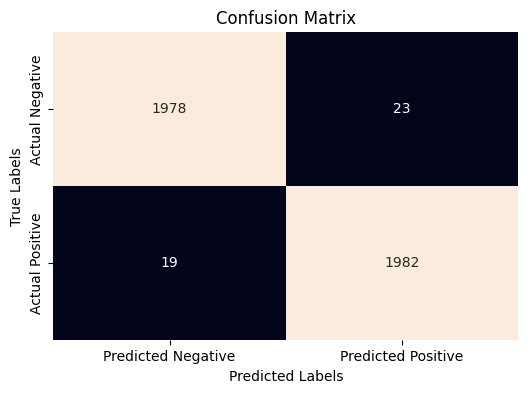

In [85]:
#Create a heatmap to visualize the confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.heatmap(cm_accuracy, annot=True, fmt='d', cbar=False,
             xticklabels=['Predicted Negative', 'Predicted Positive'],
             yticklabels=['Actual Negative', 'Actual Positive'])

plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [86]:
x_test.shape

(4002, 17)

In [87]:

#Evaluating the model with Precision Score
ps_prediction = model.predict(x_test)

ps_accuracy = precision_score(y_test, ps_prediction)
ps_accuracy

0.9885286783042394

In [88]:

# Evaluating the model with recall score
rs_prediction = model.predict(x_test)

# Calculate recall score
rs_accuracy = recall_score(y_test, rs_prediction)
rs_accuracy

0.9905047476261869

In [89]:

#Evaluating the model to know the accuracy the test data

x_test_prediction = model.predict(x_test)

test_data_accuracy = accuracy_score(y_test, x_test_prediction)

In [90]:
   
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_auc_score, roc_curve

import matplotlib.pyplot as plt

Text(0.5, 1.0, 'ROC Curve')

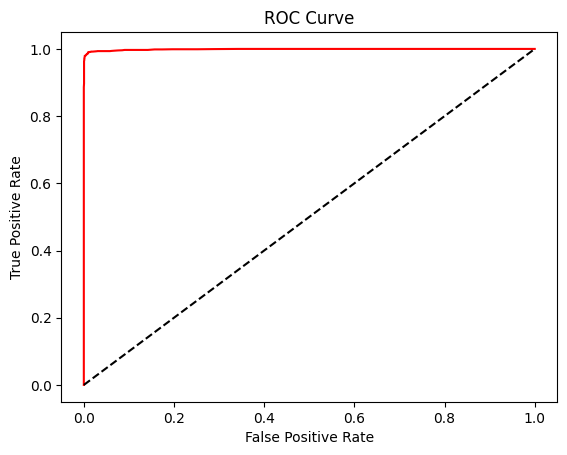

In [91]:
# Probabilities for the positive class
y_prob = model.predict_proba(x_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds =  roc_curve(y_test, y_prob)
# Ploting ROC curve
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}', color='red')
plt.plot([0,1], [0,1], 'k--')  # baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

In [92]:
#!pip install shap

In [93]:
# !pip install --upgrade ipywidgets
# !pip install --upgrade jupyter

In [94]:
# import shap

# # Initializing SHAP
# explainer = shap.Explainer(model, x_train)

# # Calculating SHAP values for the test set
# shap_values = explainer(x_test)

# # Visualize the SHAP values
# shap.summary_plot(shap_values, x_test)